<a href="https://colab.research.google.com/github/NidhiDekate/MIMIC_Demo_Mortality_Prediction/blob/main/MIMIC_Demo_Mortality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting ICU Mortality using Machine Learning

we build a machine learning pipeline to predict ICU mortality using clinical features from a healthcare dataset derived from MIMIC.

The goal is to demonstrate how machine learning can be applied to healthcare data for risk prediction and clinical decision support.

Workflow:

1. Data loading and exploration
2. Data preprocessing
3. Feature engineering
4. Handling class imbalance
5. Training multiple machine learning models
6. Model evaluation
7. Model explainability using SHAP

How to Run This Notebook

To reproduce this tutorial:

1. Install the required libraries (pandas, scikit-learn, xgboost, shap).
2. Load the dataset.
3. Run the notebook cells from top to bottom.

This will reproduce the preprocessing, model training, evaluation, and SHAP explainability results.

In [52]:
# Import all required libraries for data processing, machine learning, and explainability.
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# shap is used for model explainability - explaining WHY the model made each prediction.
import shap

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



*   Load MIMIC-III demo data from CSV files.
*   Demo data is publicly available at physionet.org/content/mimiciii-demo
*   No credentials needed — anyone can download and run this notebook.
*   Full MIMIC-III requires credentialing but has 40,000+ patients.
*   Demo has ~100 patients — same structure, smaller scale.








In [54]:
# Load MIMIC-III demo data directly from CSV files
patients = pd.read_csv('/content/drive/MyDrive/MIMIC_Demo/PATIENTS.csv')
admissions = pd.read_csv('/content/drive/MyDrive/MIMIC_Demo/ADMISSIONS.csv')
icustays = pd.read_csv('/content/drive/MyDrive/MIMIC_Demo/ICUSTAYS.csv')
labevents = pd.read_csv('/content/drive/MyDrive/MIMIC_Demo/LABEVENTS.csv')

# Convert date columns
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
patients['dob'] = pd.to_datetime(patients['dob'])

# Merge patients and admissions
df = admissions.merge(patients[['subject_id', 'dob', 'gender']], on='subject_id')

# MIMIC shifts DOB for patients over 89 to protect privacy causing overflow
# We cap DOB at 1900 to avoid overflow issues
patients['dob'] = pd.to_datetime(patients['dob'], errors='coerce')
patients.loc[patients['dob'].dt.year < 1900, 'dob'] = pd.NaT

df = admissions.merge(patients[['subject_id', 'dob', 'gender']], on='subject_id')

# Calculate age safely
df['age'] = df.apply(
    lambda row: min(89, max(0, (row['admittime'] - row['dob']).days // 365))
    if pd.notnull(row['dob']) else 65, axis=1
)

# Merge with ICU stays
icustays_small = icustays[['hadm_id', 'icustay_id', 'los']].copy()
df = df.merge(icustays_small, on='hadm_id')
df = df.rename(columns={'los': 'icu_los'})

# Filter age between 15 and 89
df = df[(df['age'] >= 15) & (df['age'] <= 89)]

# Extract lab values for first 24 hours
labevents['charttime'] = pd.to_datetime(labevents['charttime'])
admissions_time = admissions[['hadm_id', 'admittime']].copy()

labs = labevents.merge(admissions_time, on='hadm_id')
labs = labs[labs['charttime'] <= labs['admittime'] + pd.Timedelta(hours=24)]

# Pivot lab values using item IDs
lab_pivot = labs[labs['itemid'].isin([50912, 50971, 50983, 51221, 51301, 50960, 50893, 50882])].groupby(['hadm_id', 'itemid'])['valuenum'].mean().unstack()

lab_pivot.columns = ['bicarbonate', 'calcium', 'creatinine', 'hematocrit', 'magnesium', 'potassium', 'sodium', 'wbc']
lab_pivot = lab_pivot.reset_index()

# Final merge
df = df.merge(lab_pivot, on='hadm_id', how='left')

# Keep only needed columns
df = df[['subject_id', 'hadm_id', 'icustay_id', 'age', 'gender',
         'hospital_expire_flag', 'icu_los', 'creatinine', 'potassium',
         'sodium', 'hematocrit', 'wbc', 'magnesium', 'calcium', 'bicarbonate']]

print(df.shape)
print(df.head())

(136, 15)
   subject_id  hadm_id  icustay_id  age gender  hospital_expire_flag  icu_los  \
0       10006   142345      206504   70      F                     0   1.6325   
1       10011   105331      232110   36      F                     1  13.8507   
2       10013   165520      264446   87      F                     1   2.6499   
3       10017   199207      204881   73      F                     0   2.1436   
4       10019   177759      228977   48      M                     1   1.2938   

   creatinine   potassium  sodium  hematocrit    wbc  magnesium  calcium  \
0    3.250000  139.000000   39.65        1.35   6.20       5.20    8.950   
1    0.700000  136.000000   33.95        1.80  10.60       5.90    8.500   
2    1.700000  137.000000   28.65        1.30  15.00       4.15    9.050   
3    0.533333  138.666667   36.85        2.00  24.15       4.30    8.700   
4    5.800000  137.600000   32.44        2.05   5.10       4.40    8.075   

   bicarbonate  
0         30.0  
1         23

In [55]:
# Check data types and non-null counts for each column.
# This helps identify which columns have missing values and whether
# data types are correct before preprocessing.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            136 non-null    int64  
 1   hadm_id               136 non-null    int64  
 2   icustay_id            136 non-null    int64  
 3   age                   136 non-null    int64  
 4   gender                136 non-null    object 
 5   hospital_expire_flag  136 non-null    int64  
 6   icu_los               136 non-null    float64
 7   creatinine            136 non-null    float64
 8   potassium             136 non-null    float64
 9   sodium                136 non-null    float64
 10  hematocrit            130 non-null    float64
 11  wbc                   136 non-null    float64
 12  magnesium             135 non-null    float64
 13  calcium               128 non-null    float64
 14  bicarbonate           136 non-null    float64
dtypes: float64(9), int64(5)

In [56]:
# Count missing values in each column.
# Columns with too many missing values (>50%) will be dropped
# as filling them would mean guessing rather than using real data.
df.isnull().sum()

,0
subject_id,0
hadm_id,0
icustay_id,0
age,0
gender,0
hospital_expire_flag,0
icu_los,0
creatinine,0
potassium,0
sodium,0


In [57]:
# Summary statistics for all numeric columns.
# Helps identify outliers, data ranges, and distribution of features
# before preprocessing.
df.describe()

,subject_id,hadm_id,icustay_id,age,hospital_expire_flag,icu_los,creatinine,potassium,sodium,hematocrit,wbc,magnesium,calcium,bicarbonate
count,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,130.000000,136.000000,135.000000,128.000000,136.000000
mean,28263.485294,153259.566176,250980.470588,68.742647,0.338235,4.452457,1.375772,139.306495,31.717719,2.052038,11.924001,4.209160,8.356194,24.636642
std,16008.281510,28054.220280,28455.125832,15.331882,0.474858,6.196828,1.279795,5.826006,4.684665,0.379307,7.836985,0.568768,0.774155,4.990255
min,10006.000000,100375.000000,201006.000000,17.000000,0.000000,0.105900,0.400000,119.500000,22.433333,1.300000,0.300000,3.133333,4.700000,10.000000
25%,10089.750000,129028.000000,224359.250000,63.000000,0.000000,1.233525,0.750000,136.000000,27.981250,1.800000,6.600000,3.783333,7.862500,21.500000
50%,40307.000000,157724.000000,250055.000000,70.000000,0.000000,2.111450,1.070833,139.500000,31.350000,2.012500,10.250000,4.175000,8.358333,24.500000
75%,42207.000000,174896.500000,277279.250000,81.000000,1.000000,4.329050,1.437500,142.000000,35.350000,2.200000,14.731250,4.520000,8.850000,27.500000
max,44228.000000,199395.000000,298685.000000,88.000000,1.000000,35.406500,10.900000,163.500000,41.350000,3.500000,67.066667,5.900000,10.975000,42.000000


In [58]:
# Check unique values in the gender column before encoding.
# Gender is stored as 'M' and 'F' strings - we need to convert to numbers
# because machine learning models require numeric input.
df['gender'].value_counts()

,count
gender,
M,73
F,63


In [59]:
# Convert gender to binary numeric values.
# M = 1, F = 0 — simple binary mapping since there are only two categories.
# We use map() instead of LabelEncoder because we want explicit control
# over which value gets which number.
df['gender'] = df['gender'].map({'M': 1, 'F': 0})

In [60]:
# Fill missing values in lab columns with the median of each column.
# We use median instead of mean because ICU lab values are often skewed
# by extreme values from critically ill patients.
# Median is more robust to outliers than mean.
# We fill all numeric lab columns at once using a list for efficiency.
cols = ['icu_los','creatinine','potassium','sodium','hematocrit','wbc','magnesium','calcium','bicarbonate']
df[cols] = df[cols].fillna(df[cols].median())

In [61]:
# Verify no missing values remain after preprocessing.
df.isnull().sum()

,0
subject_id,0
hadm_id,0
icustay_id,0
age,0
gender,0
hospital_expire_flag,0
icu_los,0
creatinine,0
potassium,0
sodium,0


In [62]:
# Confirm preprocessing looks correct.
df.head()

,subject_id,hadm_id,icustay_id,age,gender,hospital_expire_flag,icu_los,creatinine,potassium,sodium,hematocrit,wbc,magnesium,calcium,bicarbonate
0,10006,142345,206504,70,0,0,1.6325,3.250000,139.000000,39.65,1.35,6.20,5.20,8.950,30.0
1,10011,105331,232110,36,0,1,13.8507,0.700000,136.000000,33.95,1.80,10.60,5.90,8.500,23.0
2,10013,165520,264446,87,0,1,2.6499,1.700000,137.000000,28.65,1.30,15.00,4.15,9.050,29.0
3,10017,199207,204881,73,0,0,2.1436,0.533333,138.666667,36.85,2.00,24.15,4.30,8.700,27.0
4,10019,177759,228977,48,1,1,1.2938,5.800000,137.600000,32.44,2.05,5.10,4.40,8.075,14.0


In [63]:
# Check class balance of our target variable.
# hospital_expire_flag: 0 = survived, 1 = died.
# This tells us if we have an imbalanced dataset which affects
# how we train and evaluate our models.
df['hospital_expire_flag'].value_counts()

,count
hospital_expire_flag,
0,90
1,46


In [64]:
# Separate features (X) and target variable (y).
# We drop ID columns (subject_id, hadm_id, icustay_id) because they are
# just identifiers with no predictive value.
# We drop hospital_expire_flag as it is our target, not a feature.
X, y = df.drop(['subject_id', 'hadm_id', 'icustay_id','hospital_expire_flag'], axis=1), df['hospital_expire_flag']

In [65]:
# Split data into 80% training and 20% testing.
# random_state=42 ensures reproducibility - same split every time.
# We never touch the test set during training to get an honest evaluation.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [81]:
# Confirm train/test split shapes are correct.
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((108, 11), (28, 11), (108,), (28,))

In [67]:
# Scale features for Logistic Regression using StandardScaler.
# Logistic Regression is sensitive to feature scale - age (15-89) and
# sodium (130-150) are on very different scales without scaling.
# fit_transform on train: learns mean/std FROM training data and transforms it.
# transform on test: uses the SAME mean/std learned from training - never fits on test data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Training

Train three models:

- Logistic Regression
- Random Forest
- XGBoost

In [68]:
# Logistic Regression
# Train Logistic Regression as our baseline model.
# class_weight='balanced' tells the model to penalize mistakes on the minority
# class (deaths) more heavily, helping with our 88/12 class imbalance.
# We use scaled features since Logistic Regression is sensitive to feature magnitude.
clf1 = LogisticRegression(class_weight='balanced', random_state=42)
clf1.fit(X_train_scaled, y_train)
y_pred_lr = clf1.predict(X_test_scaled)

Model Evaluation

Evaluate models using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

In [69]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.71      0.60      0.65        20
           1       0.27      0.38      0.32         8

    accuracy                           0.54        28
   macro avg       0.49      0.49      0.48        28
weighted avg       0.58      0.54      0.55        28



In [70]:
# Random Forest
# Train Random Forest with hyperparameter tuning using GridSearchCV.
# We tune max_depth, n_estimators, and min_samples_leaf.
# scoring='recall' because in healthcare, missing a death is worse than a false alarm.
# cv=5 means 5-fold cross validation - more reliable than a single train/test split.
# class_weight='balanced' handles class imbalance.
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [1, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42),
    param_grid,
    cv=5,
    scoring='recall')

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best params: {'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV score: 0.6178571428571429


In [71]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_best_rf))

              precision    recall  f1-score   support

           0       0.78      0.70      0.74        20
           1       0.40      0.50      0.44         8

    accuracy                           0.64        28
   macro avg       0.59      0.60      0.59        28
weighted avg       0.67      0.64      0.65        28



In [72]:
# Train XGBoost classifier.
# scale_pos_weight handles class imbalance.
# This tells XGBoost that the positive class (deaths) should be weighted
# Value is set based on ratio of survivors to deaths in training data.
# No scaling needed - tree based models are not sensitive to feature scale.
xgb = XGBClassifier(scale_pos_weight=7.5, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.80      0.60      0.69        20
           1       0.38      0.62      0.48         8

    accuracy                           0.61        28
   macro avg       0.59      0.61      0.58        28
weighted avg       0.68      0.61      0.63        28



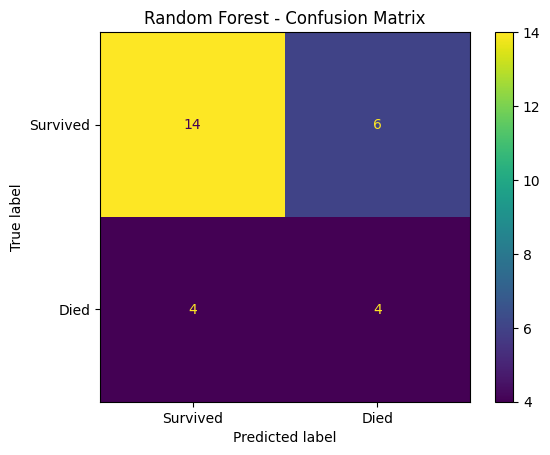

In [73]:
# Confusion matrix shows true positives, false positives, true negatives, false negatives.
# In healthcare, false negatives (missed deaths) are the most critical errors.
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Died'])
disp.plot()
plt.title('Random Forest - Confusion Matrix')
plt.show()

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression
lr_pred = clf1.predict(X_test_scaled)
lr_prob = clf1.predict_proba(X_test_scaled)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

# Random Forest
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

# XGBoost
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

In [75]:
# Compare all three models across multiple metrics.
# We prioritize recall because missing a high-risk patient is more dangerous
# than a false alarm in a clinical setting.

# AUC-ROC
# Calculate AUC-ROC score for the best Random Forest model.
# AUC-ROC measures the model's ability to distinguish between survivors and deaths.
# Score of 1.0 = perfect, 0.5 = random guessing.
# We use predict_proba to get probability scores, not just 0/1 predictions.

from sklearn.metrics import roc_auc_score
print("AUC-ROC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [lr_acc, rf_acc, xgb_acc],
    "Precision": [lr_prec, rf_prec, xgb_prec],
    "Recall": [lr_rec, rf_rec, xgb_rec],
    "F1 Score": [lr_f1, rf_f1, xgb_f1],
    "ROC-AUC": [lr_auc, rf_auc, xgb_auc]
})

results

AUC-ROC: 0.58125


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.535714,0.272727,0.375,0.315789,0.47500
1,Random Forest,0.642857,0.400000,0.500,0.444444,0.58125
2,XGBoost,0.607143,0.384615,0.625,0.476190,0.71250


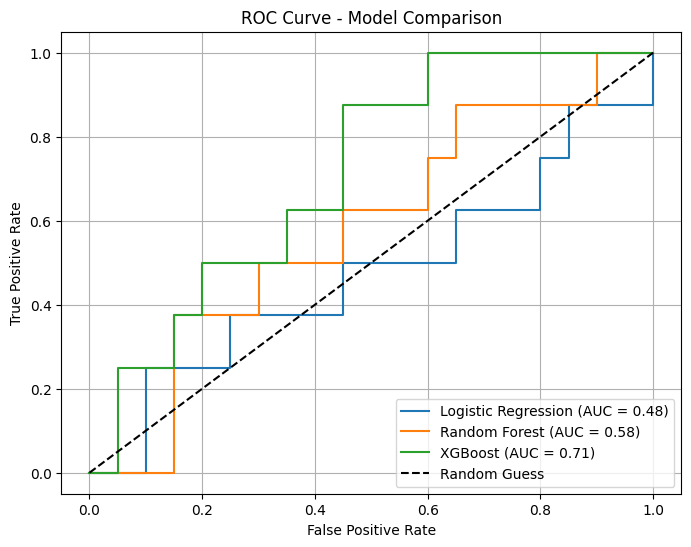

In [76]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

# Plot all 3 on one graph
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend()
plt.grid(True)
plt.show()

## Final Model Selection

Since this is a healthcare prediction problem, recall is the most important metric — it shows how many high-risk patients the model correctly identifies.

Based on the evaluation results, we select the model with the highest recall as our final model for SHAP analysis.

Note: Results may vary depending on the dataset size. This notebook uses the MIMIC-III demo dataset (~100 patients). On the full MIMIC-III dataset, Random Forest achieved the highest recall (0.698).

Model Explainability with SHAP

Use SHAP to understand which features contribute most to mortality prediction and visualize feature importance.

SHAP shape: (28, 11)
X_test shape: (28, 11)


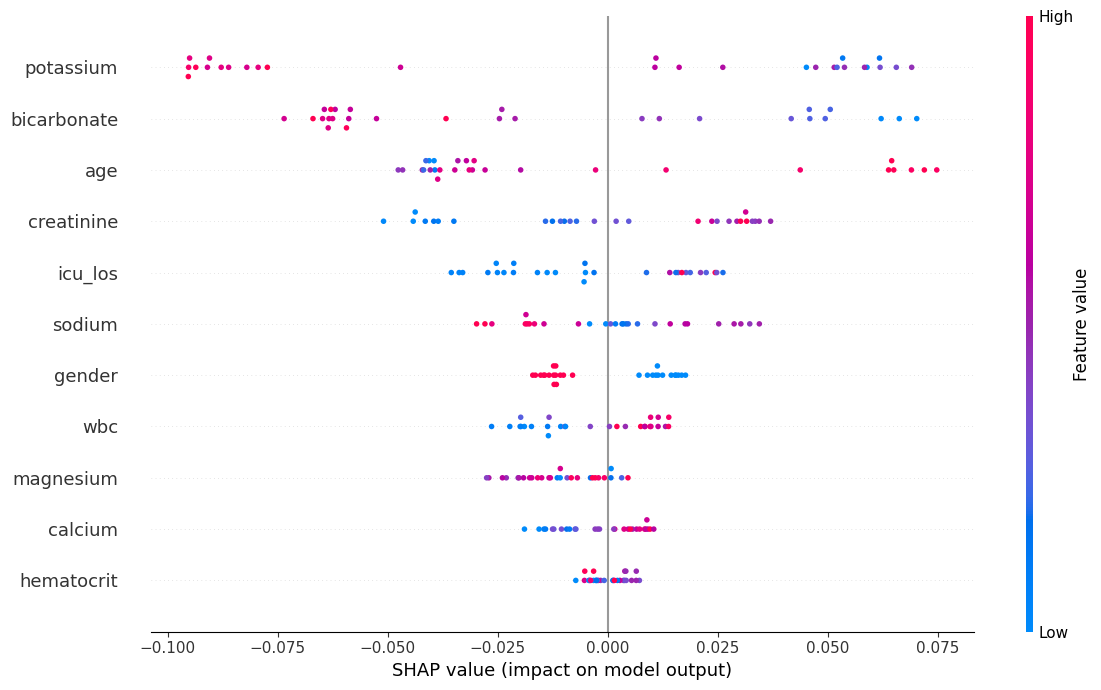

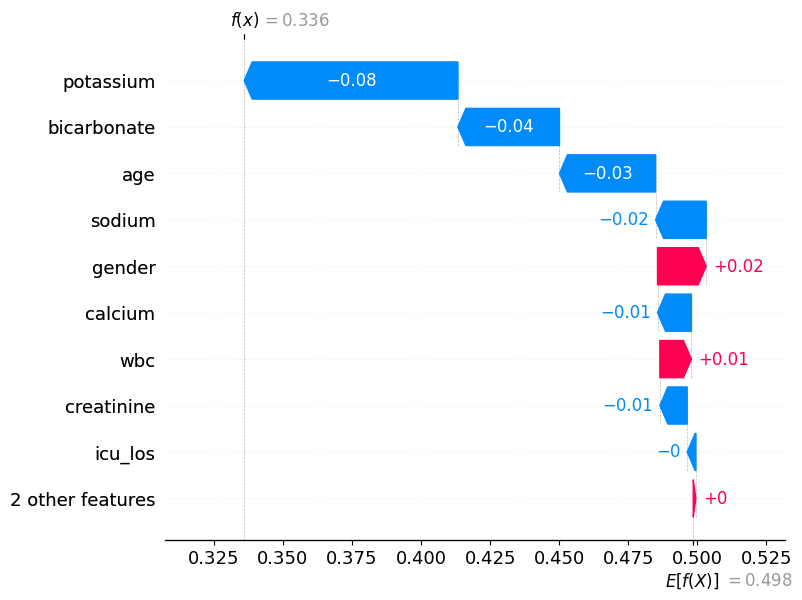

<Figure size 640x480 with 0 Axes>

In [77]:
# Apply SHAP (SHapley Additive Explanations) to explain model predictions.
# SHAP tells us how much each feature contributed to each individual prediction.
# This is critical in healthcare - doctors need to understand WHY a model
# predicts high mortality risk before acting on it.
# TreeExplainer is optimized for tree-based models like Random Forest.

explainer = shap.TreeExplainer(best_rf)
raw_shap = explainer.shap_values(X_test)

if isinstance(raw_shap, list):
    sv = raw_shap[1]
    base_value = explainer.expected_value[1]
elif hasattr(raw_shap, "values"):
    if raw_shap.values.ndim == 3:
        sv = raw_shap.values[:, :, 1]
        base_value = raw_shap.base_values[0, 1] if np.ndim(raw_shap.base_values) > 1 else raw_shap.base_values[0]
    else:
        sv = raw_shap.values
        base_value = raw_shap.base_values[0] if np.ndim(raw_shap.base_values) > 0 else raw_shap.base_values
else:
    if raw_shap.ndim == 3:
        sv = raw_shap[:, :, 1]
        base_value = explainer.expected_value[1]
    else:
        sv = raw_shap
        base_value = explainer.expected_value

print("SHAP shape:", sv.shape)
print("X_test shape:", X_test.shape)


#SHAP summary plot
plt.figure(figsize=(12, 7))
shap.summary_plot(
    sv,
    X_test,
    feature_names=X_test.columns.tolist(),
    show=False,
    plot_size=(12, 7)
)
plt.tight_layout()
plt.show()

#SHAP waterfall plot for one sample
sample_idx = 0

plt.figure(figsize=(6, 6))
shap.plots._waterfall.waterfall_legacy(
    base_value,
    sv[sample_idx],
    feature_names=X_test.columns.tolist(),
    max_display=10
)
plt.tight_layout()
plt.show()

In [78]:
import joblib

# Save the best model and scaler for deployment
# This allows the model to be loaded without retraining
joblib.dump(best_rf, 'icu_mortality_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved successfully")

Model saved successfully


In [80]:
import joblib
import numpy as np

def predict_mortality(age, gender, icu_los, creatinine, potassium,
                      sodium, hematocrit, wbc, magnesium, calcium, bicarbonate):
    """
    Predict ICU mortality risk for a single patient.

    Parameters: clinical features from first 24 hours of ICU stay
    Returns: mortality risk probability and SHAP explanation
    """
    # Load saved model
    model = joblib.load('icu_mortality_model.pkl')

    # Create patient feature array
    patient = pd.DataFrame([[age, gender, icu_los, creatinine, potassium,
                         sodium, hematocrit, wbc, magnesium, calcium, bicarbonate]],
                       columns=['age', 'gender', 'icu_los', 'creatinine', 'potassium',
                                'sodium', 'hematocrit', 'wbc', 'magnesium', 'calcium', 'bicarbonate'])

    # Predict
    risk_prob = model.predict_proba(patient)[0][1]
    prediction = "HIGH RISK" if risk_prob > 0.5 else "LOW RISK"

    print(f"Mortality Risk: {prediction}")
    print(f"Risk Probability: {risk_prob:.2%}")

    return risk_prob

# Example: predict for a new patient
predict_mortality(
    age=70, gender=1, icu_los=3.5,
    creatinine=2.1, potassium=4.2, sodium=138,
    hematocrit=28, wbc=12.5, magnesium=1.8,
    calcium=8.5, bicarbonate=22
)

Mortality Risk: HIGH RISK
Risk Probability: 56.37%


np.float64(0.5637411988699739)